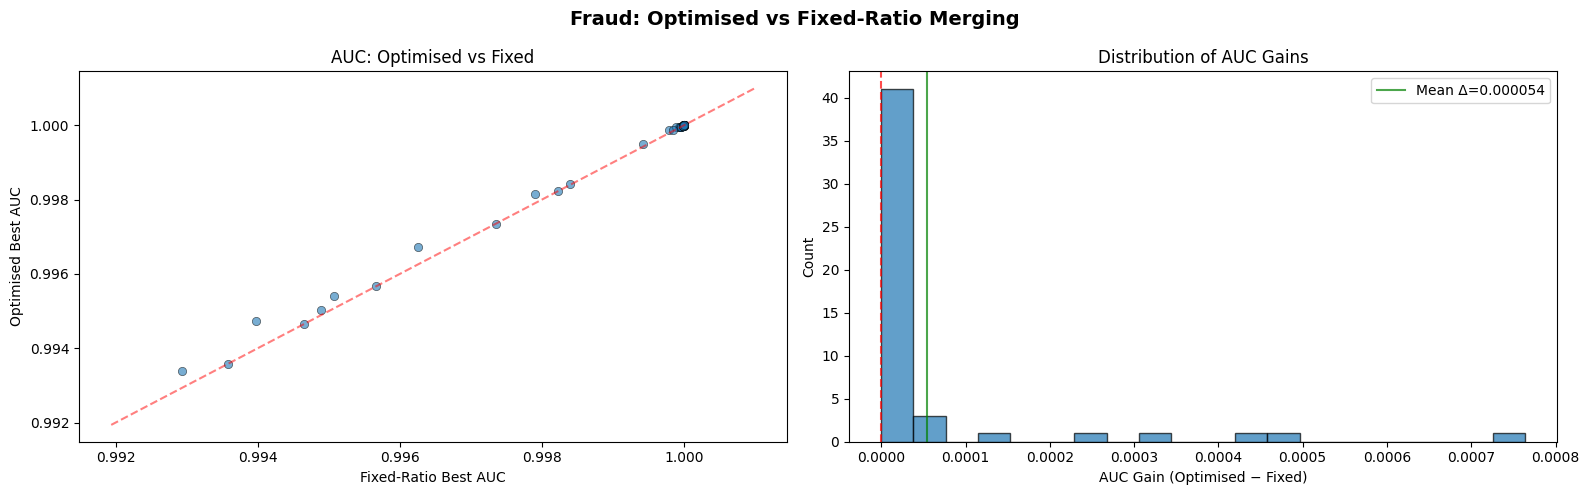

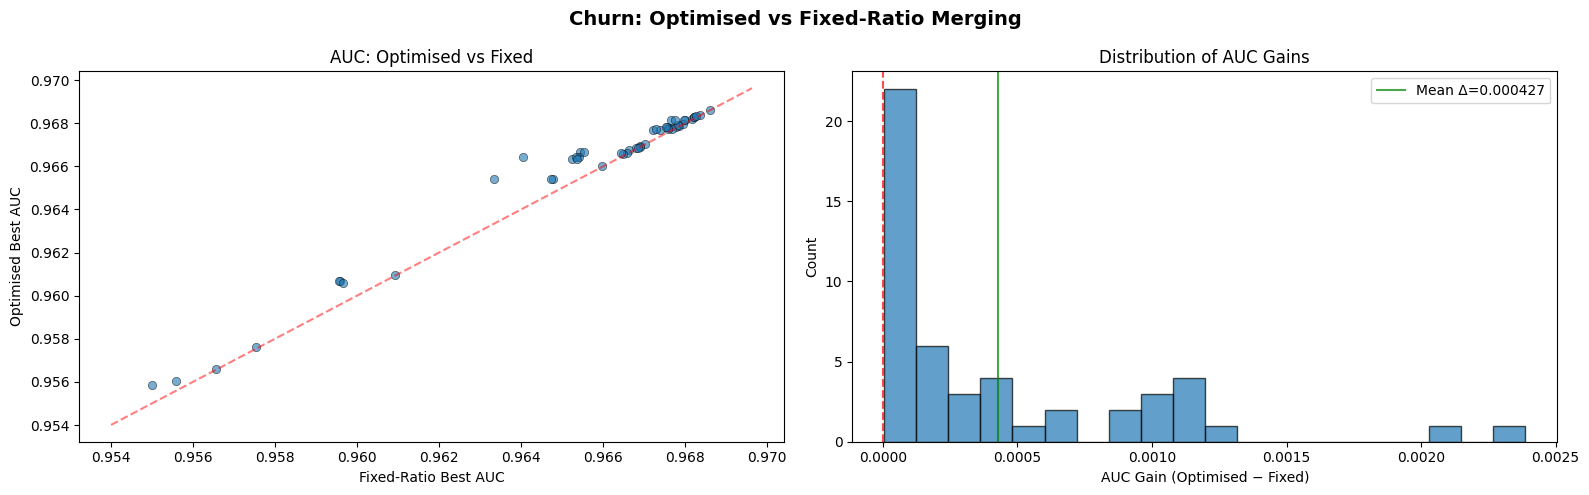

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_m2n2_comparison(results_csv: str, task_name: str):
    df = pd.read_csv(results_csv)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f"{task_name}: Optimised vs Fixed-Ratio Merging",
        fontsize=14, fontweight="bold"
    )

    # 1)AUC scatter
    ax = axes[0]
    ax.scatter(
        df["fixed_best_auc"], df["opt_best_auc"],
        alpha=0.6, edgecolors="k", linewidth=0.5
    )
    lo = min(df["fixed_best_auc"].min(), df["opt_best_auc"].min()) - 0.001
    hi = max(df["fixed_best_auc"].max(), df["opt_best_auc"].max()) + 0.001
    ax.plot([lo, hi], [lo, hi], "r--", alpha=0.5)
    ax.set_xlabel("Fixed-Ratio Best AUC")
    ax.set_ylabel("Optimised Best AUC")
    ax.set_title("AUC: Optimised vs Fixed")

    # 2)distribution
    ax = axes[1]
    delta = df["opt_vs_fixed"]
    ax.hist(delta, bins=20, edgecolor="black", alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", alpha=0.7)
    ax.axvline(
        delta.mean(), color="green", linestyle="-",
        alpha=0.7, label=f"Mean Δ={delta.mean():.6f}"
    )
    ax.set_xlabel("AUC Gain (Optimised − Fixed)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of AUC Gains")
    ax.legend()

    plt.tight_layout()
    out = f"../results/merges/{task_name.lower()}/m2n2_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()

plot_m2n2_comparison("../results/merges/fraud/m2n2_results.csv", "Fraud")
plot_m2n2_comparison("../results/merges/churn/m2n2_results.csv", "Churn")